# Car Data Analysis Project

This notebook performs a comprehensive analysis of car data including data cleaning, feature engineering, exploratory data analysis, and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("data.csv")

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (11914, 16)

First few rows:


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## 1. Data Cleaning

In [2]:
# 1.1.1 Identify missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64


In [3]:
# 1.1.2 Handle missing data
# Drop rows with missing critical values
df = df.dropna(subset=["Engine HP", "Engine Cylinders", "Number of Doors", "MSRP"])

# Fill categorical missing values with 'unknown'
df["Market Category"] = df["Market Category"].fillna("unknown")
df["Engine Fuel Type"] = df["Engine Fuel Type"].fillna("unknown")

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Market Category      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64


In [4]:
# 1.2 Data type conversion
df["Year"] = df["Year"].astype(int)

# 1.3 Filter cars from 1995 onwards
df = df[df["Year"] >= 1995]

print(f"Dataset shape after filtering: {df.shape}")
print(f"Year range: {df['Year'].min()} - {df['Year'].max()}")

Dataset shape after filtering: (10993, 16)
Year range: 1995 - 2017


In [5]:
# 1.4 String operations - Standardize text entries
df["Vehicle Style"] = df["Vehicle Style"].str.lower()
df["Market Category"] = df["Market Category"].str.lower()

print("Sample of standardized vehicle styles:")
print(df["Vehicle Style"].unique()[:10])

Sample of standardized vehicle styles:
<StringArray>
[            'coupe',       'convertible',             'sedan',
     '4dr hatchback',             'wagon',     '2dr hatchback',
           '4dr suv', 'passenger minivan',     'cargo minivan',
   'crew cab pickup']
Length: 10, dtype: str


## 2. Feature Engineering

In [6]:
# 2.1 Create Total MPG column (average of city mpg and highway MPG)
df["Total MPG"] = (df["city mpg"] + df["highway MPG"]) / 2

# 2.2 Create Price per HP column
df["Price per HP"] = df["MSRP"] / df["Engine HP"]

print("New engineered features:")
print(df[["Total MPG", "Price per HP"]].describe())

New engineered features:
          Total MPG  Price per HP
count  10993.000000  10993.000000
mean      22.996498    149.499854
std        6.804705     97.153200
min        9.500000      7.142857
25%       19.000000    116.492537
50%       22.000000    137.340426
75%       26.500000    164.741641
max      189.000000   2307.692308


## 3. Exploratory Data Analysis

In [7]:
# 3.1 Descriptive statistics
stats_columns = ["Engine HP", "MSRP", "Popularity", "highway MPG", "city mpg"]
stats = df[stats_columns].describe()

print("Descriptive Statistics:")
print(stats)

Descriptive Statistics:
          Engine HP          MSRP    Popularity   highway MPG      city mpg
count  10993.000000  1.099300e+04  10993.000000  10993.000000  10993.000000
mean     256.833348  4.342755e+04   1567.713272     26.527063     19.465933
std      108.752882  6.153328e+04   1452.044123      7.527027      6.647618
min       55.000000  2.000000e+03      2.000000     12.000000      7.000000
25%      176.000000  2.299500e+04    549.000000     22.000000     16.000000
50%      240.000000  3.125000e+04   1385.000000     26.000000     18.000000
75%      304.000000  4.349000e+04   2009.000000     31.000000     22.000000
max     1001.000000  2.065902e+06   5657.000000    354.000000    137.000000


In [8]:
# 3.2 Group analysis
# Group by Driven_Wheels
group_dw = df.groupby("Driven_Wheels")[["MSRP", "Popularity"]].mean()

# Group by Vehicle Size
group_vs = df.groupby("Vehicle Size")[["MSRP", "Popularity"]].mean()

# Group by Engine Cylinders
group_cyl = df.groupby("Engine Cylinders")[["MSRP", "Popularity"]].mean()

print("Average MSRP and Popularity by Driven Wheels:")
print(group_dw)

print("\nAverage MSRP and Popularity by Vehicle Size:")
print(group_vs)

print("\nAverage MSRP and Popularity by Engine Cylinders:")
print(group_cyl)

Average MSRP and Popularity by Driven Wheels:
                           MSRP   Popularity
Driven_Wheels                               
all wheel drive    59397.279373  1510.259791
four wheel drive   38460.878220  1760.016393
front wheel drive  24647.835391  1397.152492
rear wheel drive   60469.092434  1775.516118

Average MSRP and Popularity by Vehicle Size:
                      MSRP   Popularity
Vehicle Size                           
Compact       37774.332549  1474.730009
Large         56786.953650  1906.314407
Midsize       40886.589836  1451.799615

Average MSRP and Popularity by Engine Cylinders:
                          MSRP   Popularity
Engine Cylinders                           
0.0               3.451192e+04  1986.538462
3.0               1.354700e+04   791.950000
4.0               2.554803e+04  1435.978340
5.0               2.285833e+04   856.418719
6.0               3.649050e+04  1693.402635
8.0               6.555978e+04  1756.037368
10.0              1.841238e+05  1830

## 4. Visualizations

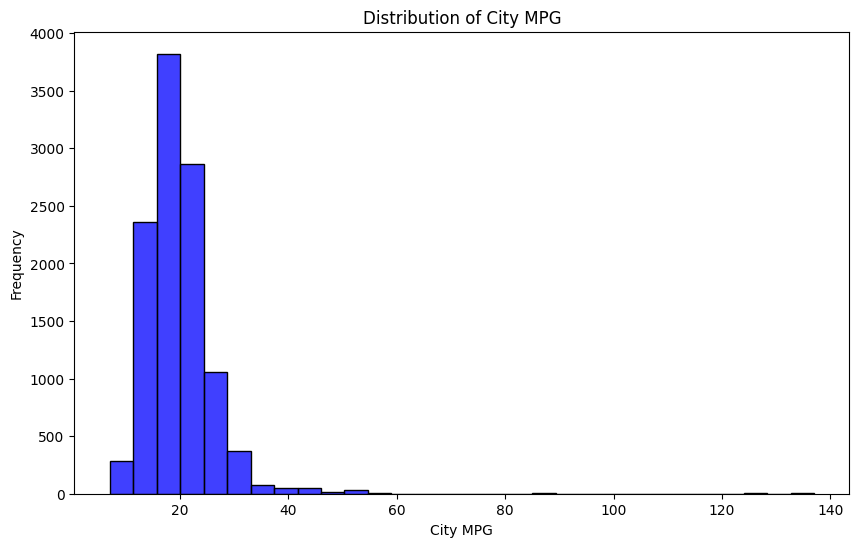

In [16]:
# 4.1 Histogram: City MPG Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['city mpg'], bins=30, color='blue', edgecolor='black')
plt.title('Distribution of City MPG')
plt.xlabel('City MPG')
plt.ylabel('Frequency')
plt.show()

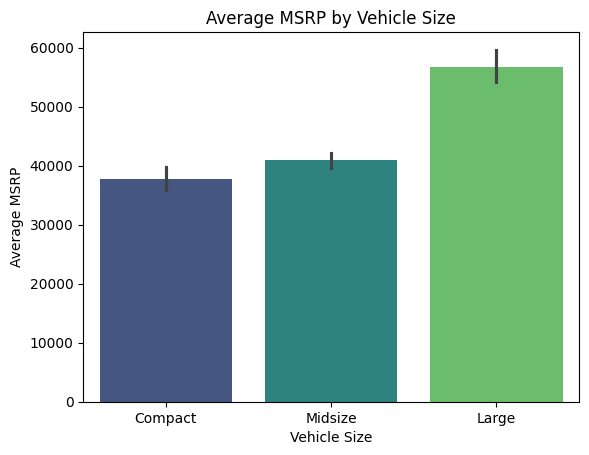

In [17]:
# 4.2 Bar chart: Average MSRP by Vehicle Size
fig, ax = plt.subplots()
sns.barplot(x='Vehicle Size', y='MSRP', hue='Vehicle Size', data=df, palette='viridis', legend=False)
ax.set_title('Average MSRP by Vehicle Size')
ax.set_xlabel('Vehicle Size')
ax.set_ylabel('Average MSRP')
plt.show()

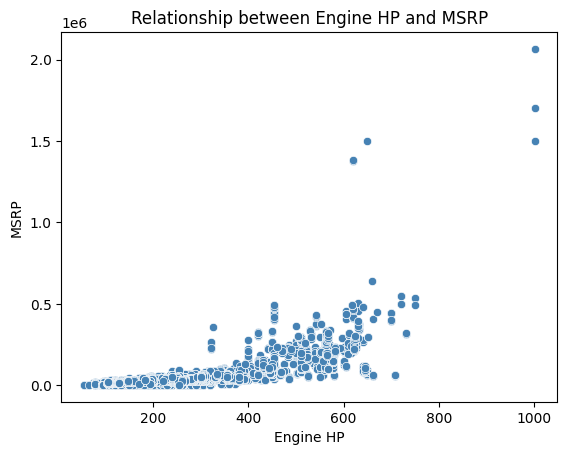

In [18]:
# 4.3 Scatter plot of Engine HP vs. MSRP
fig, ax = plt.subplots()
sns.scatterplot(x='Engine HP', y='MSRP', data=df, color='steelblue')
plt.title('Relationship between Engine HP and MSRP')
plt.xlabel('Engine HP')
plt.ylabel('MSRP')
plt.show()

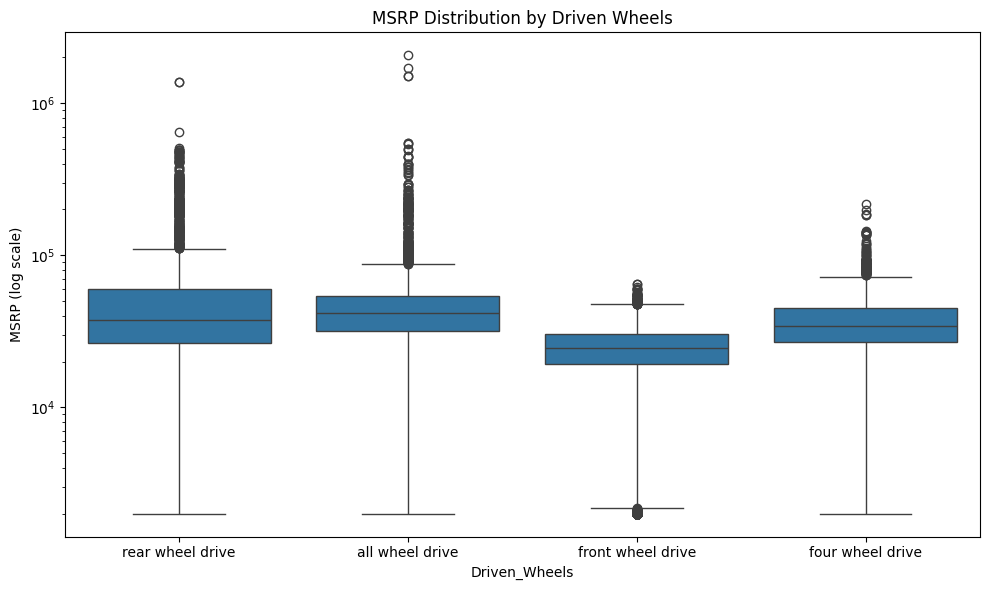

In [24]:
# 4.4 Boxplot: MSRP by Driven Wheels
plt.figure(figsize=(10, 6))
sns.boxplot(x="Driven_Wheels", y="MSRP", data=df)
plt.title("MSRP Distribution by Driven Wheels")
plt.ylabel("MSRP (log scale)")
plt.yscale("log")
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

In [28]:
# 5.1 Correlation matrix
corr_columns = ["Engine HP", "MSRP", "Popularity", "city mpg", "highway MPG"]
corr = df[corr_columns].corr(numeric_only=True)

print("Correlation Matrix:")
print(corr)

Correlation Matrix:
             Engine HP      MSRP  Popularity  city mpg  highway MPG
Engine HP     1.000000  0.654172    0.030789 -0.497202    -0.451193
MSRP          0.654172  1.000000   -0.057243 -0.246750    -0.225402
Popularity    0.030789 -0.057243    1.000000 -0.011594    -0.030791
city mpg     -0.497202 -0.246750   -0.011594  1.000000     0.843070
highway MPG  -0.451193 -0.225402   -0.030791  0.843070     1.000000


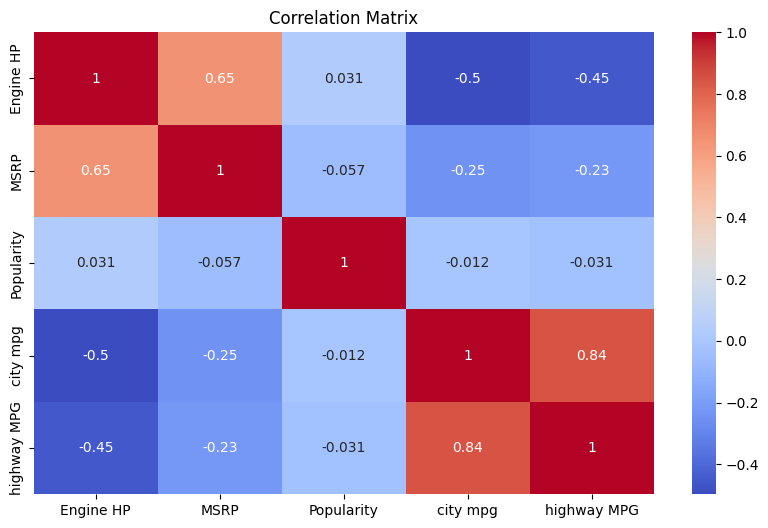

In [29]:
# 5.2 Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 6. Summary and Insights

This analysis revealed several key insights about the car dataset:

1. **Data Quality**: The dataset required significant cleaning including handling missing values and filtering for cars from 1995 onwards.

2. **Feature Engineering**: Created two new features - Total MPG and Price per HP - to provide additional analytical perspectives.

3. **Price Relationships**: Engine HP shows a positive correlation with MSRP, while fuel efficiency metrics show negative correlations.

4. **Vehicle Categories**: Different vehicle sizes and drive wheel types show distinct pricing patterns.

5. **Market Trends**: The analysis provides insights into how various factors influence car pricing and popularity.